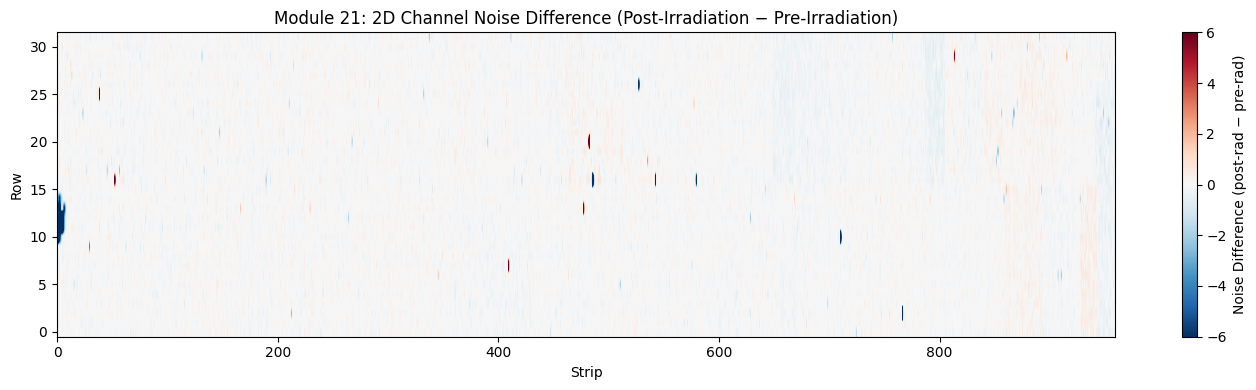

In [4]:
# import necessary packages
import uproot
import numpy as np
import matplotlib.pyplot as plt


# define fxn to read 2d histogram and return values
def read_th2(root_file, path):

    with uproot.open(root_file) as f:
        hist = f[path]
        values, x_edges, y_edges = hist.to_numpy(flow=False)

    return values, x_edges, y_edges


#define fxn to find difference between noise pre rad cold and noise post rad
def diff_th2_paths(root_pre, path_pre,
                   root_post, path_post):

    values_pre, _, _ = read_th2(root_pre, path_pre)
    values_post, _, _ = read_th2(root_post, path_post)

    return values_post - values_pre


#define fxn to create file paths for files pre rad
def make_pre_histpath(hybrid, chip):

    return (
        f"Detector/Board_0/OpticalGroup_1/"
        f"Hybrid_{hybrid}/"
        f"MPA_{chip}/"
        f"D_B(0)_O(1)_H({hybrid})"
        f"_2DChannelNoise_Chip({chip});1"
    )

#define fxn to  create file paths for files post rad in mod21
def make_post_histpath(hybrid, chip):

    return (
        f"Iteration_3_PSfullTest_2026-03-13_08-45-57/"
        f"Detector/Board_0/OpticalGroup_2/"
        f"Hybrid_{hybrid}/"
        f"MPA_{chip}/"
        f"D_B(0)_O(2)_H({hybrid})"
        f"_2DChannelNoise_Chip({chip});1"
    )


#defines root files pre and post rad
root_pre = (
    "PS_16_FNL-10021_2025-12-02_04h37m52s_-33C_PSfullTest_v6-22.root"
)

root_post = (
    "/home/ekimrey/QPT_before_irradiation/"
    "post_irradiation_for_Emerson/"
    "TrackerHistos/TrackerHistos_42.root"
)

#create numpy array of zeroes thats the same size as final dataset
combined = np.zeros((32, 960))


#pre rad hybrid 3 = post rad hybrid 5 and will be in top half of final hist
for i, chip in enumerate(range(8, 16)):

    path_pre = make_pre_histpath(3, chip)
    path_post = make_post_histpath(5, chip)

    diff = diff_th2_paths(
        root_pre,
        path_pre,
        root_post,
        path_post
    )
    
    chip_img = diff.T
    chip_img = np.flipud(chip_img)

    c0 = i * 120
    c1 = c0 + 120

    combined[16:32, c0:c1] = chip_img


# pre rad hybrid 2 = post rad hybrid 4, will be in bottom half of final hist
for i, chip in enumerate(range(15, 7, -1)):

    path_pre = make_pre_histpath(2, chip)
    path_post = make_post_histpath(4, chip)

    diff = diff_th2_paths(
        root_pre,
        path_pre,
        root_post,
        path_post
    )

    chip_img = diff.T
    chip_img = np.fliplr(chip_img)

    c0 = i * 120
    c1 = c0 + 120

    combined[0:16, c0:c1] = chip_img

#plot
fig, ax = plt.subplots(figsize=(14, 4))

im = ax.imshow(
    combined,
    origin="lower",
    aspect="auto",
    cmap="RdBu_r",
    vmin=-6,
    vmax=6
)

fig.colorbar(
    im,
    ax=ax,
    label="Noise Difference (post-rad − pre-rad)"
)

ax.set_title(
    "Module 21: 2D Channel Noise Difference "
    "(Post-Irradiation − Pre-Irradiation)"
)

ax.set_xlabel("Strip")
ax.set_ylabel("Row")

plt.tight_layout()
plt.savefig("m21_rad_noise_difference_map.png", dpi=150)
plt.savefig("m21_rad_noise_difference_map.pdf")
plt.show()

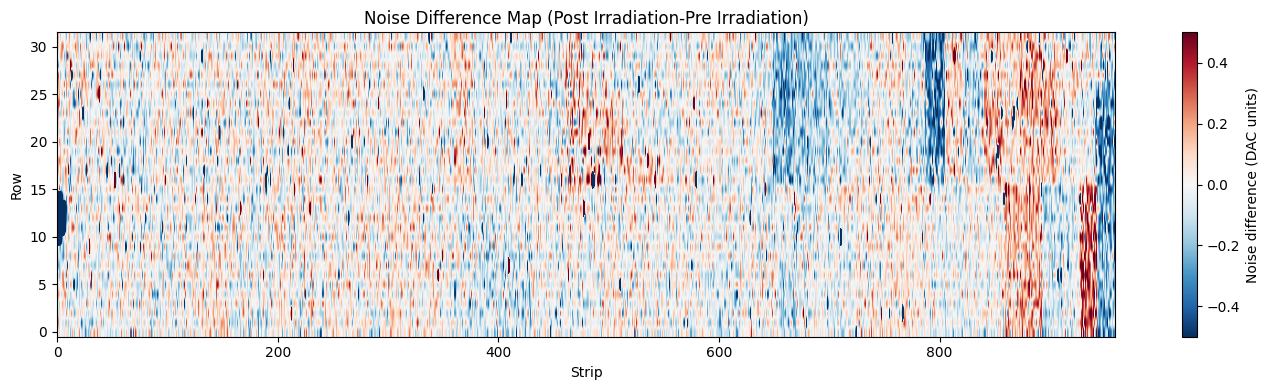

In [5]:
# changes scale
fig, ax = plt.subplots(figsize=(14, 4))

im = ax.imshow(
    combined,
    origin="lower",
    aspect="auto",
    cmap="RdBu_r",
    vmin=-0.5,
    vmax=0.5
)

fig.colorbar(im, ax=ax, label="Noise difference (DAC units)")
ax.set_xlabel("Strip")
ax.set_ylabel("Row")
ax.set_title("Noise Difference Map (Post Irradiation-Pre Irradiation)")

plt.tight_layout()
plt.savefig("m21_rad_noise_difference_map_scaled.png", dpi=150)
plt.savefig("m21_rad_noise_difference_map_scaled.pdf")
plt.show()

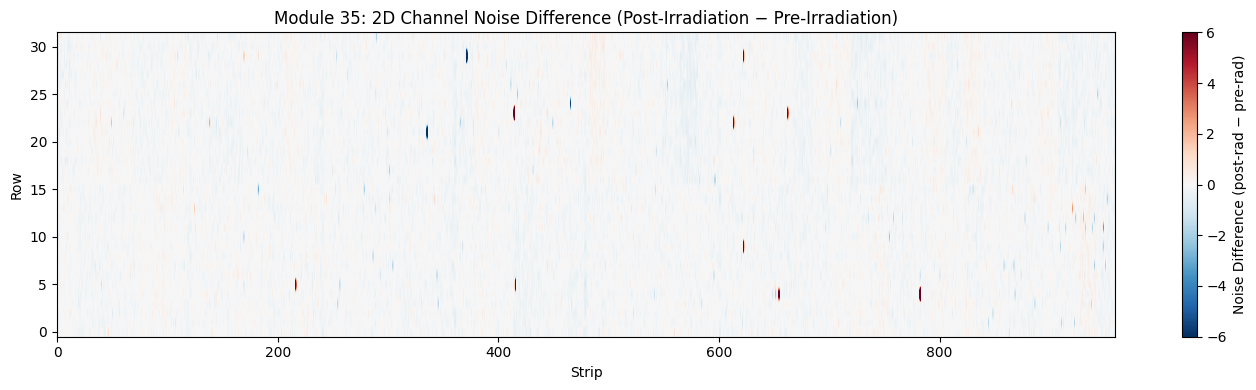

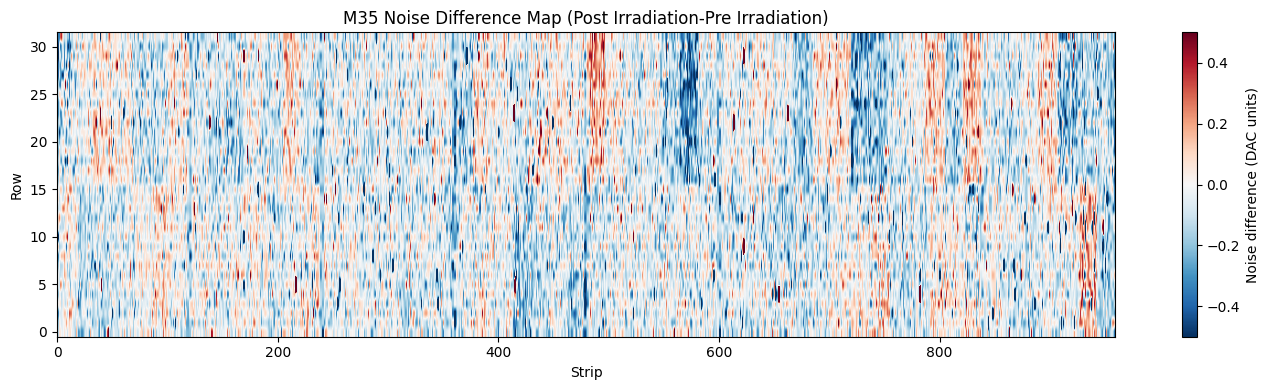

In [6]:
# import necessary packages
import uproot
import numpy as np
import matplotlib.pyplot as plt


# define fxn to read 2d histogram and return values
def read_th2(root_file, path):

    with uproot.open(root_file) as f:
        hist = f[path]
        values, x_edges, y_edges = hist.to_numpy(flow=False)

    return values, x_edges, y_edges


#define fxn to find difference between noise pre rad cold and noise post rad
def diff_th2_paths(root_pre, path_pre,
                   root_post, path_post):

    values_pre, _, _ = read_th2(root_pre, path_pre)
    values_post, _, _ = read_th2(root_post, path_post)

    return values_post - values_pre


#define fxn to create file paths for files pre rad
def make_pre_histpath(hybrid, chip):

    return (
        f"Detector/Board_0/OpticalGroup_5/"
        f"Hybrid_{hybrid}/"
        f"MPA_{chip}/"
        f"D_B(0)_O(5)_H({hybrid})"
        f"_2DChannelNoise_Chip({chip});1"
    )

#define fxn to  create file paths for files post rad in mod21
def make_post_histpath(hybrid, chip):

    return (
        f"Iteration_3_PSfullTest_2026-03-13_08-45-57/"
        f"Detector/Board_0/OpticalGroup_1/"
        f"Hybrid_{hybrid}/"
        f"MPA_{chip}/"
        f"D_B(0)_O(1)_H({hybrid})"
        f"_2DChannelNoise_Chip({chip});1"
    )


#defines root files pre and post rad
root_pre = (
    "PS_16_FNL-10035_2025-12-02_04h37m52s_-33C_PSfullTest_v6-22.root"
)

root_post = (
    "/home/ekimrey/QPT_before_irradiation/"
    "post_irradiation_for_Emerson/"
    "TrackerHistos/TrackerHistos_42.root"
)

#create numpy array of zeroes thats the same size as final dataset
combined = np.zeros((32, 960))


#pre rad hybrid 3 = post rad hybrid 5 and will be in top half of final hist
for i, chip in enumerate(range(8, 16)):

    path_pre = make_pre_histpath(11, chip)
    path_post = make_post_histpath(3, chip)

    diff = diff_th2_paths(
        root_pre,
        path_pre,
        root_post,
        path_post
    )
    
    chip_img = diff.T
    chip_img = np.flipud(chip_img)

    c0 = i * 120
    c1 = c0 + 120

    combined[16:32, c0:c1] = chip_img


# pre rad hybrid 2 = post rad hybrid 4, will be in bottom half of final hist
for i, chip in enumerate(range(15, 7, -1)):

    path_pre = make_pre_histpath(10, chip)
    path_post = make_post_histpath(2, chip)

    diff = diff_th2_paths(
        root_pre,
        path_pre,
        root_post,
        path_post
    )

    chip_img = diff.T
    chip_img = np.fliplr(chip_img)

    c0 = i * 120
    c1 = c0 + 120

    combined[0:16, c0:c1] = chip_img

#plot
fig, ax = plt.subplots(figsize=(14, 4))

im = ax.imshow(
    combined,
    origin="lower",
    aspect="auto",
    cmap="RdBu_r",
    vmin=-6,
    vmax=6
)

fig.colorbar(
    im,
    ax=ax,
    label="Noise Difference (post-rad − pre-rad)"
)

ax.set_title(
    "Module 35: 2D Channel Noise Difference "
    "(Post-Irradiation − Pre-Irradiation)"
)

ax.set_xlabel("Strip")
ax.set_ylabel("Row")

plt.tight_layout()
plt.show()

# changes scale
fig, ax = plt.subplots(figsize=(14, 4))

im = ax.imshow(
    combined,
    origin="lower",
    aspect="auto",
    cmap="RdBu_r",
    vmin=-0.5,
    vmax=0.5
)

fig.colorbar(im, ax=ax, label="Noise difference (DAC units)")
ax.set_xlabel("Strip")
ax.set_ylabel("Row")
ax.set_title("M35 Noise Difference Map (Post Irradiation-Pre Irradiation)")

plt.tight_layout()
plt.show()